In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import OrdinalEncoder

In [3]:
house= pd.read_csv("A:\\AIML_DEV_FOLDER\\Dataset_self\\House Price Prediction Dataset.csv")

In [4]:
X = house.drop(columns=['YearBuilt','Location','Condition','Garage','Price'
])
y = house.iloc[:,-1] # last colmun ""

In [5]:
X = house.drop(columns=['YearBuilt', 'Location', 'Condition', 'Garage', 'Price'])
y = house.iloc[:, -1]  # Last column 'Price'

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 5)
y shape: (2000,)


In [13]:
house.describe()

,ID,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
print(X.dtypes)
print("\nColumn names:")
print(list(X.columns))

ID           int64
Area         int64
Bedrooms     int64
Bathrooms    int64
Floors       int64
dtype: object

Column names:
['ID', 'Area', 'Bedrooms', 'Bathrooms', 'Floors']


In [8]:
# Applying Regression without any transformation
lr = LinearRegression()

lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

r2_score(y_test,y_pred)

-0.010819168265362666

In [9]:
# Cross checking with cross val score
lr = LinearRegression()
np.mean(cross_val_score(lr,X,y,scoring='r2'))

np.float64(-0.004795609885695074)

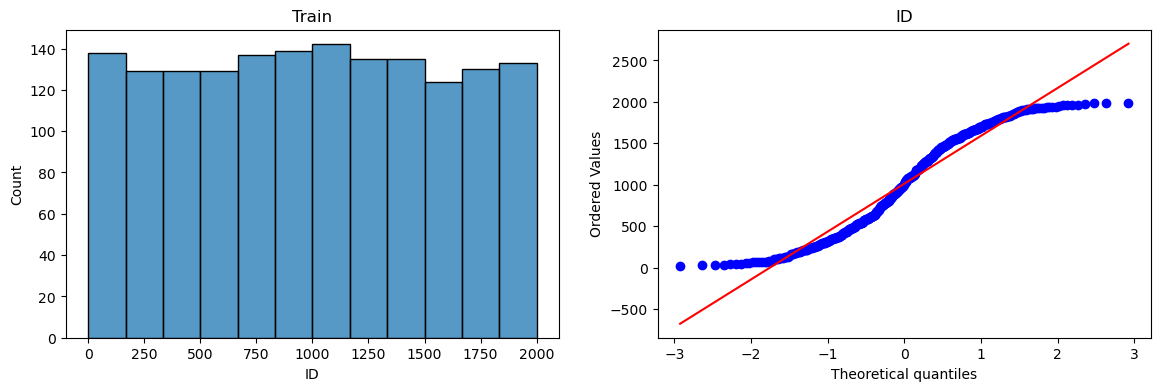

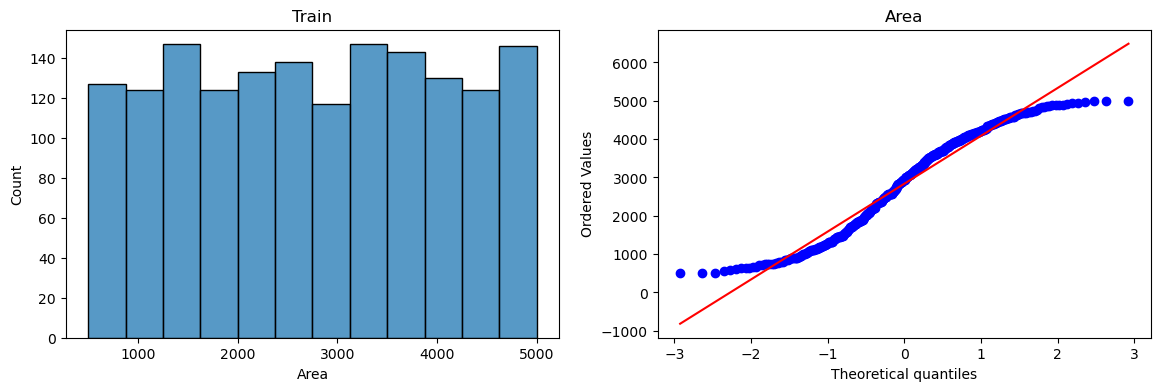

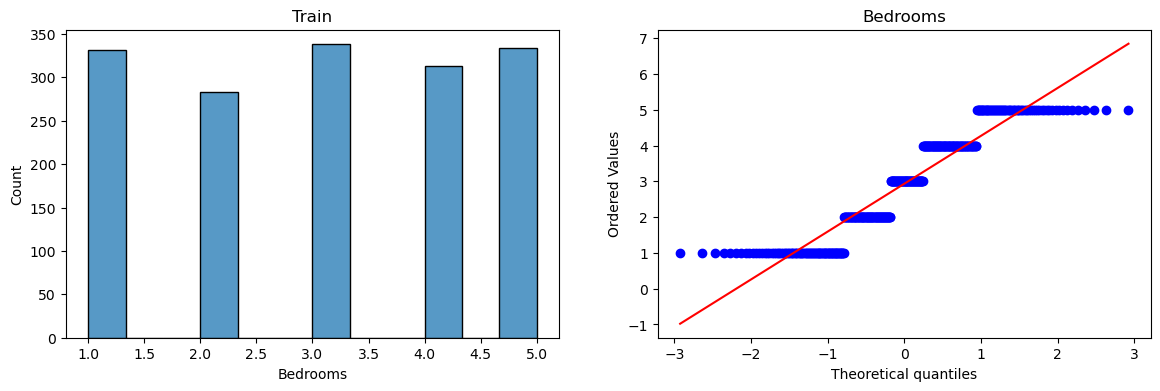

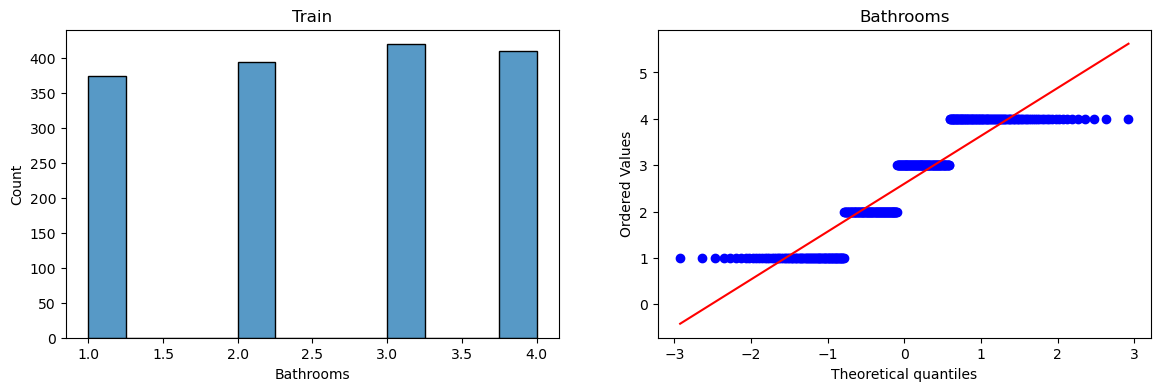

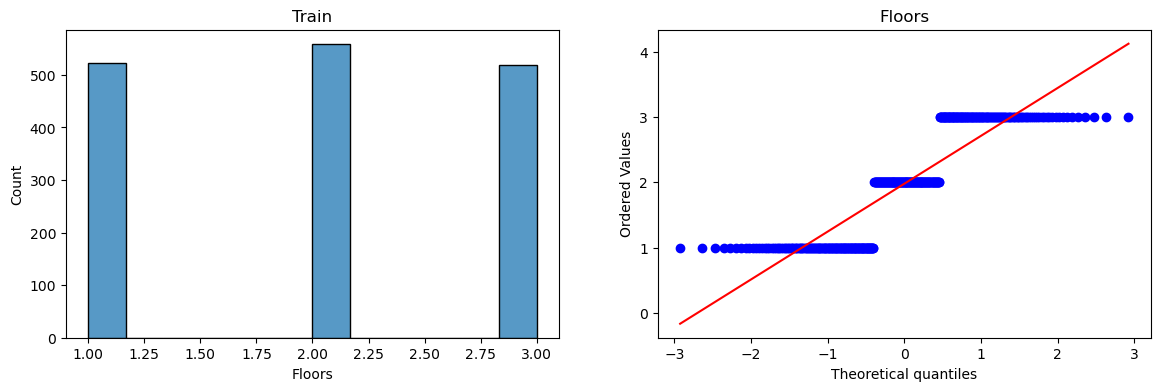

In [11]:
for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col])
    plt.title("Train")
    plt.subplot(122)
    stats.probplot(X_test[col],dist='norm',plot=plt)
    plt.title(col)
    plt.show()

# har ek column ke lamda value calculate hoga

In [ ]:
# Applying Box-Cox Transform
pt = PowerTransformer(method='box-cox')
